<a href="https://colab.research.google.com/github/de-fernandez/CPE-313-CPE32S3/blob/main/%5BGroup%2010%5D%2C%20CPE32S3%2C%20CPE%20313%20(Hands-On-Activity%207.1%20-%20CNN%20Architectures%2C%20Regularization%20and%20Transfer%20Learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Kenn Jie Valleser <br>
Don Eleazar Fernandez**

https://www.kaggle.com/datasets/yusufemir/lemon-quality-dataset

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/CPE313/HOA7.1/lemon"
categories = ["bad_quality", "good_quality"]

data = []
labels = []
img_size = 128

for label, category in enumerate(categories):
    folder = os.path.join(base_path, category)
    for img_name in os.listdir(folder):
        try:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (img_size, img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            data.append(img)
            labels.append(label)
        except:
            pass

X = np.array(data)
y = np.array(labels)

X = X / 255.0

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
class EpochAccuracyLogger(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.train_acc = []
        self.val_acc = []

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            self.train_acc.append(logs.get('accuracy'))
            self.val_acc.append(logs.get('val_accuracy'))

# 1. CNN

In [ ]:
cnn = models.Sequential([
    Input(shape=(img_size, img_size, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,841 (108.75 KB)

 Trainable params: 27,841 (108.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
one_cnn = cnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    callbacks=[EpochAccuracyLogger()],
    verbose=1
)

Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - accuracy: 0.6422 - loss: 0.6450 - val_accuracy: 0.6370 - val_loss: 0.6189
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7102 - loss: 0.5481 - val_accuracy: 0.7500 - val_loss: 0.5105
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7265 - loss: 0.5269 - val_accuracy: 0.7596 - val_loss: 0.5125
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7572 - loss: 0.4927 - val_accuracy: 0.7668 - val_loss: 0.4798
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7735 - loss: 0.4724 - val_accuracy: 0.7861 - val_loss: 0.4623
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7837 - loss: 0.4546 - val_accuracy: 0.7644 - val_loss: 0.4740
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7886 - loss: 0.4537 - val_accuracy: 0.7548 - val_loss: 0.4936
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8084 - loss: 0.4171 - val_accuracy: 0.7812 - v

Interpretation:This model learned steadily

# 2. CNN + Regularization

In [ ]:
cnn_reg = models.Sequential([
    layers.Input(shape=(img_size, img_size, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu',
                  kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])
cnn_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_reg.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,225 (110.25 KB)

 Trainable params: 28,033 (109.50 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
history_reg = cnn_reg.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    verbose=1
)


Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.8687 - loss: 0.3443 - val_accuracy: 0.5409 - val_loss: 0.6801
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9307 - loss: 0.2015 - val_accuracy: 0.5409 - val_loss: 0.7273
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9416 - loss: 0.1593 - val_accuracy: 0.5409 - val_loss: 0.8412
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9578 - loss: 0.1245 - val_accuracy: 0.5409 - val_loss: 0.8768
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9627 - loss: 0.1118 - val_accuracy: 0.5409 - val_loss: 0.8674
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9687 - loss: 0.0987 - val_accuracy: 0.5409 - val_loss: 0.7136
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9711 - loss: 0.0859 - val_accuracy: 0.5409 - val_loss: 1.1463
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9705 - loss: 0.0795 - val_accuracy: 0.5481 - 

Interpretation: The accuracy bounced up and down and inconsistent

# 3. TRANSFER LEARNING (FEATURE EXTRACTION)

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False

model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model_tl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_tl.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history_tl = model_tl.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    verbose=1
)

Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 31s 302ms/step - accuracy: 0.8247 - loss: 0.4209 - val_accuracy: 0.9712 - val_loss: 0.1872
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9699 - loss: 0.1521 - val_accuracy: 0.9832 - val_loss: 0.1063
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9807 - loss: 0.1025 - val_accuracy: 0.9880 - val_loss: 0.0788
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9855 - loss: 0.0800 - val_accuracy: 0.9832 - val_loss: 0.0655
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9861 - loss: 0.0677 - val_accuracy: 0.9904 - val_loss: 0.0582
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9867 - loss: 0.0575 - val_accuracy: 0.9904 - val_loss: 0.0509
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9880 - loss: 0.0510 - val_accuracy: 0.9904 - val_loss: 0.0456
Epoch 8/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9886 - loss: 0.0470 - val_accuracy: 0.9880 -

Interpretation : It reached nearly 99% accuracy almost immediately

# 4. TRANSFER LEARNING (FINE TUNING)

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model_ft = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model_ft.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])
model_ft.summary()


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,527,681 (5.83 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [ ]:

history_ft = model_ft.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    verbose=1
)

Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 26s 235ms/step - accuracy: 0.7916 - loss: 0.4487 - val_accuracy: 0.6466 - val_loss: 0.6161
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9446 - loss: 0.1941 - val_accuracy: 0.6394 - val_loss: 0.6104
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9765 - loss: 0.1195 - val_accuracy: 0.6587 - val_loss: 0.5896
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9807 - loss: 0.0874 - val_accuracy: 0.6947 - val_loss: 0.5628
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9898 - loss: 0.0627 - val_accuracy: 0.7139 - val_loss: 0.5364
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9861 - loss: 0.0582 - val_accuracy: 0.7524 - val_loss: 0.4795
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9922 - loss: 0.0442 - val_accuracy: 0.7788 - val_loss: 0.4458
Epoch 8/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9934 - loss: 0.0363 - val_accuracy: 0.8125 -

Interpretation:accuracy started slow then became very precise.

# Evaluation

In [ ]:
def evaluate_model(model, X_test, y_test, name):
    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    print(f"{name} Classification Report")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    auc = roc_auc_score(y_test, y_prob)
    print("ROC AUC:", auc)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title(f"ROC Curve - {name}")
    plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
CNN Classification Report
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       191
           1       0.97      1.00      0.98       225

    accuracy                           0.98       416
   macro avg       0.98      0.98      0.98       416
weighted avg       0.98      0.98      0.98       416

Confusion Matrix:
 [[184   7]
 [  1 224]]
ROC AUC: 0.9985340314136125


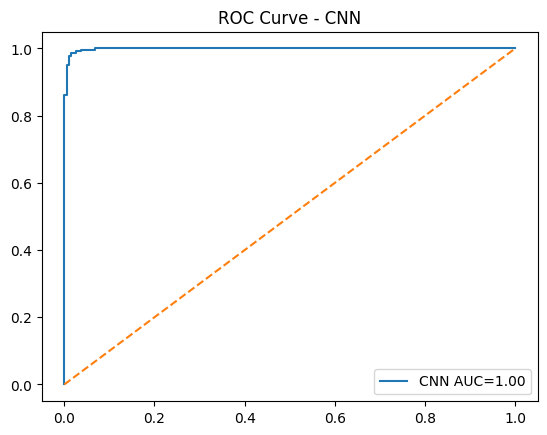

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
CNN + Regularization Classification Report
              precision    recall  f1-score   support

           0       0.99      0.92      0.95       191
           1       0.93      0.99      0.96       225

    accuracy                           0.96       416
   macro avg       0.96      0.95      0.96       416
weighted avg       0.96      0.96      0.96       416

Confusion Matrix:
 [[175  16]
 [  2 223]]
ROC AUC: 0.99369400814427


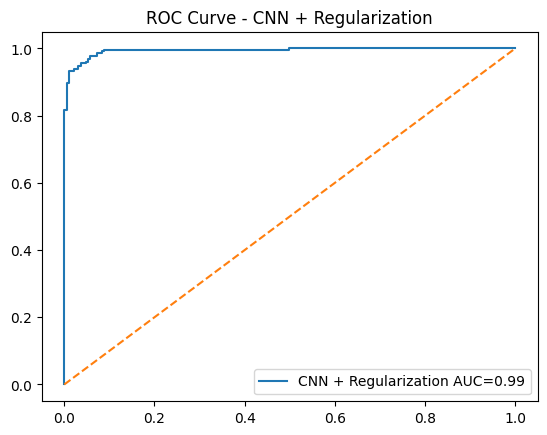

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Transfer Learning Feature Extraction Classification Report
              precision    recall  f1-score   support

           0       0.90      0.99      0.95       191
           1       1.00      0.91      0.95       225

    accuracy                           0.95       416
   macro avg       0.95      0.95      0.95       416
weighted avg       0.95      0.95      0.95       416

Confusion Matrix:
 [[190   1]
 [ 20 205]]
ROC AUC: 0.9987899941826643


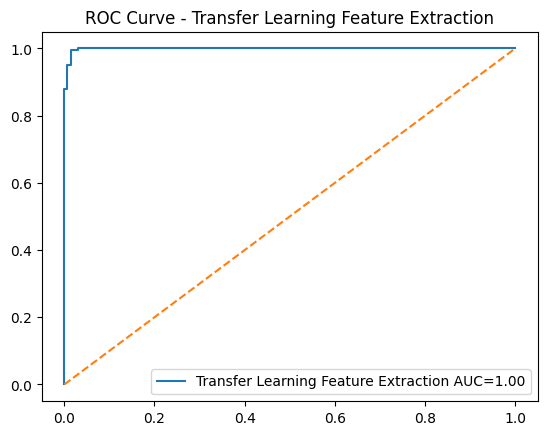

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Transfer Learning Fine Tuning Classification Report
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       191
           1       0.95      1.00      0.97       225

    accuracy                           0.97       416
   macro avg       0.97      0.97      0.97       416
weighted avg       0.97      0.97      0.97       416

Confusion Matrix:
 [[179  12]
 [  0 225]]
ROC AUC: 0.9994648051192554


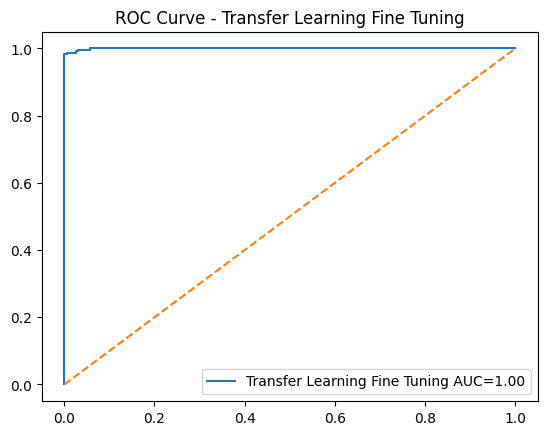

In [ ]:
evaluate_model(cnn, X_test, y_test, "CNN")
evaluate_model(cnn_reg, X_test, y_test, "CNN + Regularization")
evaluate_model(model_tl, X_test, y_test, "Transfer Learning Feature Extraction")
evaluate_model(model_ft, X_test, y_test, "Transfer Learning Fine Tuning")

Interpretation:the classification reports reveal that Transfer Learning is the best for sorting these lemons. While basic CNN did a solid job, the pre-trained MobileNetV2 models reached nearly 100% accuracy, meaning they almost never guessed wrong. These reports show high Precision and high Recall, making the imported model a very reliable. In contrast, the regularized model struggled with consistency, proving that a pre-trained model is much more efficient than building one from scratch

The Transfer Learning models (Fine-Tuning and Feature Extraction) are with AUC scores nearly at 1.00, meaning they are almost perfect at distinguishing between good and bad lemons. My Basic CNN also did surprisingly great, nearly matching the advanced models. The CNN + Regularization model, while still very accurate, has a slightly "shakier" line compared to the others, which matches the jumpy accuracy I saw during training.

In [ ]:
def plot_every_10_epochs(history, title):
    train_acc = history.history['accuracy'][::10]
    val_acc = history.history['val_accuracy'][::10]
    epochs = list(range(10, len(history.history['accuracy'])+1, 10))

    plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
    plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


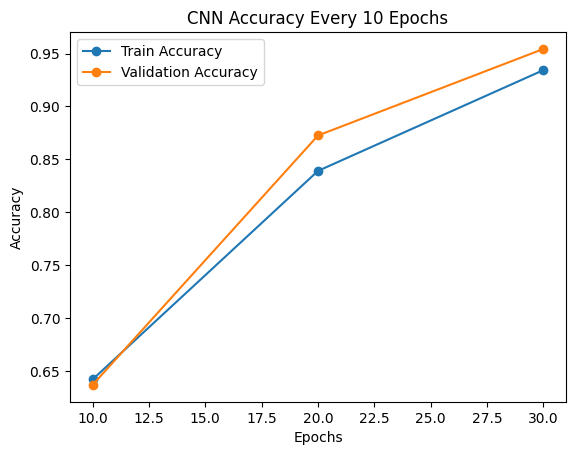

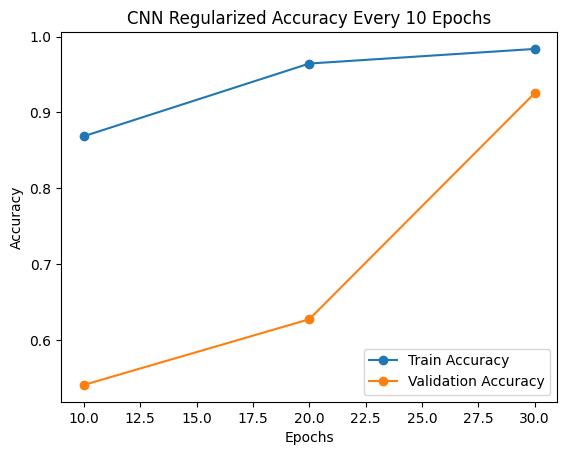

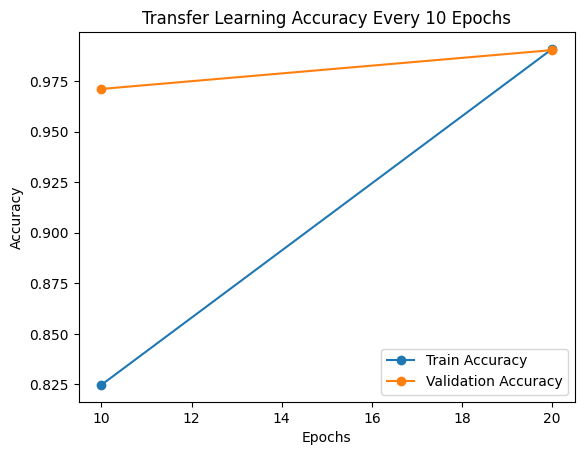

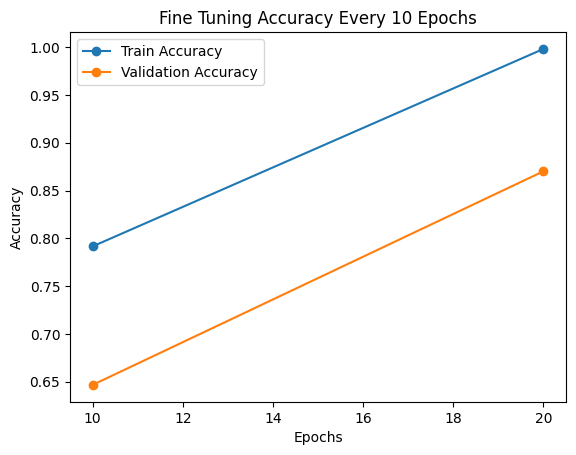

In [ ]:

plot_every_10_epochs(one_cnn, "CNN Accuracy Every 10 Epochs")
plot_every_10_epochs(history_reg, "CNN Regularized Accuracy Every 10 Epochs")
plot_every_10_epochs(history_tl, "Transfer Learning Accuracy Every 10 Epochs")
plot_every_10_epochs(history_ft, "Fine Tuning Accuracy Every 10 Epochs")

Looking at these accuracy graphs, it's clear that the models learned in very different ways. The Basic CNN was a steady learner, with both training and validation lines climbing together, showing it was actually understanding the patterns. In contrast, the Regularized CNN looks a bit problematic because the gap between the blue and orange lines is huge,it hit high training accuracy fast but struggled to apply that to the validation data, which is a classic sign of overfitting. The Transfer Learning models were the most impressive; they started at a much higher level of accuracy (above 80%) because they already had "pre-learned" knowledge, making the training process much faster and more reliable.

# **CONCLUSION**

In this activity, we trained and compared different image classification models using a lemon quality dataset. We tested a basic CNN, CNN with regularization, and two transfer learning approaches using MobileNetV2 (feature extraction and fine-tuning). The results showed that the basic CNN performed well with steady learning, while the CNN with regularization was less consistent and showed signs of unstable performance. On the other hand, both transfer learning models performed the best, reaching very high accuracy and strong results in precision, recall, and AUC score.